In [1]:
import os
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter

from polylex_chatbot.env import load_project_env
from polylex_chatbot.chunking import create_chunks
from polylex_chatbot.constants import ARTICLE_PATTERN
from polylex_chatbot.metadata import load_metadata, build_language_matched_metadata_by_doc_id

/home/saskya/dev/tb/polylex-chatbot/.venv/lib/python3.12/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
root_path = Path.cwd().parent.parent
env_file = load_project_env()
corpus_name = os.getenv("CORPUS_NAME")
metadata_dir = os.path.join(root_path, "stats", corpus_name)
corpus_dir = Path(os.path.join(root_path, "textual_contents", corpus_name))

results_path = Path("comparison_results")
results_path.mkdir(parents=True, exist_ok=True)

In [3]:
metadata = load_metadata(metadata_dir)
language_matched_metadata_by_doc_id = build_language_matched_metadata_by_doc_id(metadata)

In [4]:
def compute_results(chunks):
    print(f"Nb chunks: {len(chunks)}")
    contents = [chunk.page_content for chunk in chunks]
    content_nb_chars = [len(content) for content in contents]

    plt.hist(content_nb_chars, bins=50)
    plt.xlabel("Nb chars")
    plt.ylabel("Frequency")
    plt.show()

    print(f"Min chunk len: {min(content_nb_chars)}")
    print(f"Max chunk len: {max(content_nb_chars)}")

In [5]:
def make_split_document_function(chunk_size, chunk_overlap, is_article_pattern_used):
    if is_article_pattern_used:
        separators = [
            ARTICLE_PATTERN,
            "\n\n",
            "\n",
            " ",
            ""
        ]
    else:
        separators = [
            "\n\n",
            "\n",
            " ",
            ""
        ]
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=separators,
        is_separator_regex=True,
        keep_separator=True,
        add_start_index=True
    )
    return splitter.split_documents

In [6]:
chunking_strategies = [
    {
        "name": "small_overlap_rcts_default",
        "chunk_size": 700,
        "chunk_overlap": 100,
        "is_article_pattern_used": False
    },
    {
        "name": "small_no_overlap_rcts_article_regex",
        "chunk_size": 700,
        "chunk_overlap": 0,
        "is_article_pattern_used": True
    },
    {
        "name": "medium_overlap_rcts_default",
        "chunk_size": 2000,
        "chunk_overlap": 300,
        "is_article_pattern_used": False
    },
    {
        "name": "medium_no_overlap_rcts_article_regex",
        "chunk_size": 2000,
        "chunk_overlap": 0,
        "is_article_pattern_used": True
    },
    {
        "name": "large_overlap_rcts_default",
        "chunk_size": 5000,
        "chunk_overlap": 500,
        "is_article_pattern_used": False
    },
    {
        "name": "large_no_overlap_rcts_article_regex",
        "chunk_size": 5000,
        "chunk_overlap": 0,
        "is_article_pattern_used": True
    }
]

In [7]:
chunking_results = {}

for i, strategy in enumerate(chunking_strategies, start=1):
    strategy_name = strategy["name"]

    print(f"Testing {strategy_name} ({i})")

    split_document_function = make_split_document_function(strategy["chunk_size"], strategy["chunk_overlap"], strategy["is_article_pattern_used"])
    chunks = create_chunks(corpus_dir, language_matched_metadata_by_doc_id, split_document_function=split_document_function)

    chunking_results[strategy_name] = chunks

Testing small_overlap_rcts_default (1)
Testing small_no_overlap_rcts_article_regex (2)
Testing medium_overlap_rcts_default (3)
Testing medium_no_overlap_rcts_article_regex (4)
Testing large_overlap_rcts_default (5)
Testing large_no_overlap_rcts_article_regex (6)


Results for small_overlap_rcts_default
Nb chunks: 8410


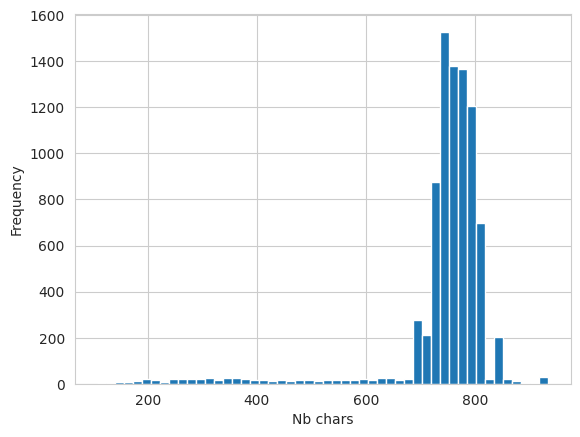

Min chunk len: 107
Max chunk len: 934
Results for small_no_overlap_rcts_article_regex
Nb chunks: 9117


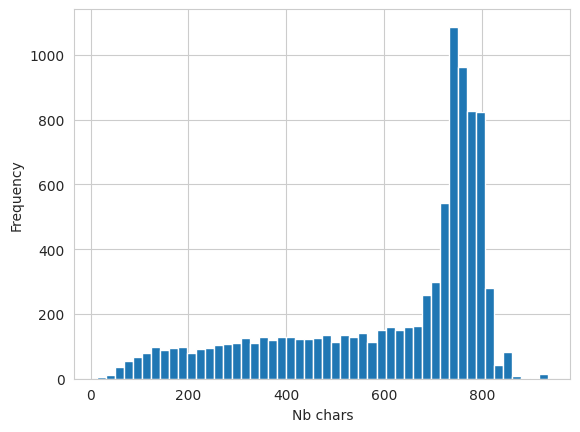

Min chunk len: 13
Max chunk len: 935
Results for medium_overlap_rcts_default
Nb chunks: 3205


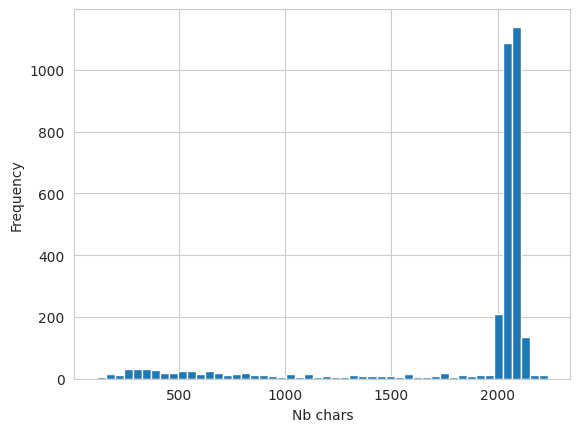

Min chunk len: 116
Max chunk len: 2235
Results for medium_no_overlap_rcts_article_regex
Nb chunks: 3520


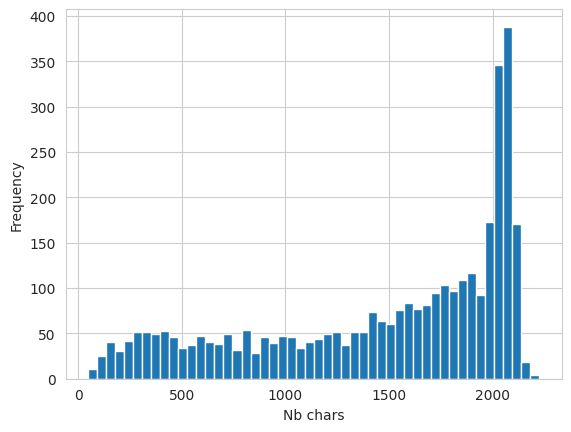

Min chunk len: 48
Max chunk len: 2225
Results for large_overlap_rcts_default
Nb chunks: 1484


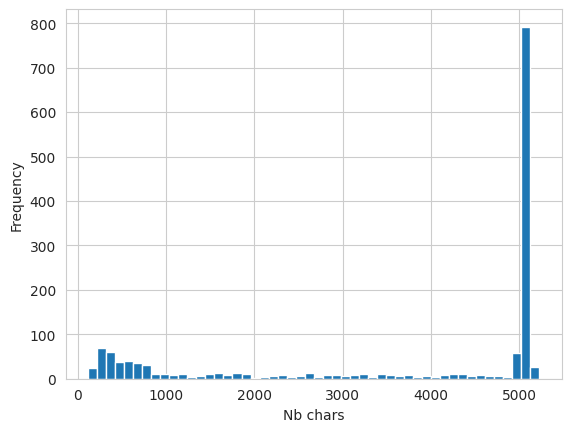

Min chunk len: 116
Max chunk len: 5225
Results for large_no_overlap_rcts_article_regex
Nb chunks: 1550


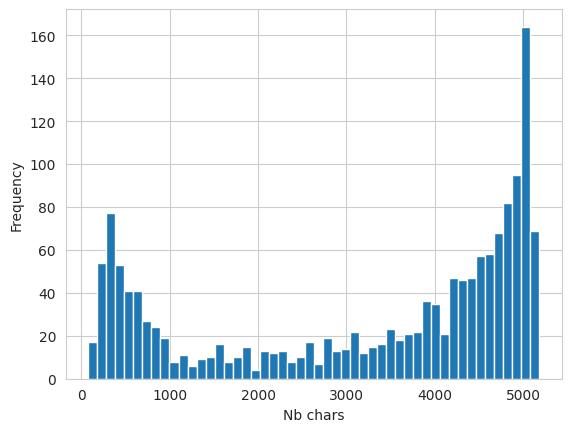

Min chunk len: 78
Max chunk len: 5183


In [8]:
for strategy_name, chunks in chunking_results.items():
    print(f"Results for {strategy_name}")
    compute_results(chunks)

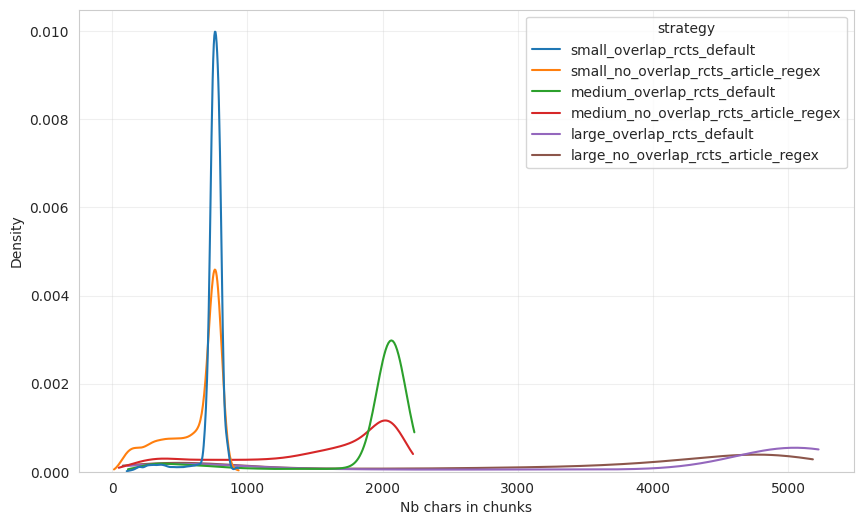

In [9]:
rows = []

for strategy_name, chunks in chunking_results.items():
    for chunk in chunks:
        rows.append({
            "strategy": strategy_name,
            "length": len(chunk.page_content)
        })

df_lengths = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_lengths,
    x="length",
    hue="strategy",
    common_norm=False,
    cut=0,
    fill=False
)

plt.xlabel("Nb chars in chunks")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

In [10]:
for strategy_name, chunks in chunking_results.items():
    output_path = os.path.join(results_path, f"chunks_{strategy_name}.txt")
    with open(output_path, "w", encoding="UTF-8") as f:
        content = "\n\n --------- \n\n".join([chunk.page_content for chunk in chunks])
        f.write(content)